In [1]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.axes import Axes
import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.size": 24,
    "font.family": "serif",
    "legend.title_fontsize": 20,
    "legend.fontsize": 18,
    "axes.labelsize": 24,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

DENSITY = 4 
HATCHES = [h * DENSITY for h in ['/', 'x', '.', '\\', '+', 'o', '|']]
COLORS = ['#5BB8D7', '#57A86B', '#A8A857', '#6E4587', '#ADEBCC', '#EBDCAD', '#F0A3FF']

In [2]:
df = (
    pl.read_csv("main_df.csv")
)
df

benchmark,accel_power_W,accel_time_us,measured_power_W,measured_time_us,idle_power_W,idle_time_us
str,f64,f64,f64,f64,f64,f64
"""deit-inference""",91.044472,7152.356007,54.731851,41999.117103,32.325223,319870.91
"""resnet50-train""",98.370075,21215.730565,70.123221,41214.817838,32.325223,690036.105
"""gpt2-train""",109.122387,43136.380742,89.669436,52817.232234,32.325223,557731.427
"""bert-inference""",96.99283,2454.583039,59.101363,10755.061665,32.325223,312991.064
"""bert-train""",106.186118,35501.958481,79.030911,53658.204805,32.325223,631781.294
"""resnet50-inference""",92.827203,4853.968198,54.032302,41119.958221,32.325223,380508.952
"""bloom-inference""",112.715731,7289.7553,74.344924,15222.401692,32.325223,553572.69
"""deit-train""",97.265104,15601.258834,68.242799,45746.64186,32.325223,653582.668
"""gpt2-inference""",92.793675,4602.412544,38.570944,22697.103064,32.325223,461579.941


In [3]:
def parity_plot(
    df: pl.DataFrame,
    x: str,
    y: str,
    hue: str,   # Column for Color/Hatch (Model)
    style: str, # Column for Shape (Phase)
    ax: Axes = None,
    ms: int = 180
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # 1. Setup Mappings
    unique_hues = df.select(hue).unique().sort(hue)[hue].to_list()
    unique_styles = df.select(style).unique().sort(style)[style].to_list()

    # Create Color/Hatch Map
    hue_map = {
        h: {
            "color": COLORS[i % len(COLORS)],
            "hatch": HATCHES[i % len(HATCHES)]
        } 
        for i, h in enumerate(unique_hues)
    }

    # Create Marker Map
    style_map = {}
    fallback_markers = ['o', 'D', 'v', '<', '>']
    marker_idx = 0
    
    for s_val in unique_styles:
        s_lower = s_val.lower() 
        if "inference" in s_lower:
            style_map[s_val] = 's' # Square
        elif "train" in s_lower:
            style_map[s_val] = '^' # Triangle
        else:
            style_map[s_val] = fallback_markers[marker_idx % len(fallback_markers)]
            marker_idx += 1

    # 2. Plotting Loop
    for (h_val, s_val), group in df.group_by([hue, style]):
        props = hue_map[h_val]
        marker = style_map[s_val]
        
        ax.scatter(
            group[x],
            group[y],
            s=ms,
            marker=marker,
            facecolor='white',
            edgecolor=props['color'],
            hatch=props['hatch'],
            zorder=3,
            linewidth=1.5,
            alpha=1.0
        )

    # 3. Diagonal Line (y=x)
    all_vals = df.select(pl.col(x), pl.col(y)).to_numpy()
    low, high = np.min(all_vals), np.max(all_vals)
    pad = (high - low) * 0.1
    limit_low = max(0, low - pad)
    limit_high = high + pad
    
    ax.plot([limit_low, limit_high], [limit_low, limit_high], 
            color='gray', linestyle='--', linewidth=2, zorder=2)

    # 4. Formatting
    ax.set_aspect('equal', adjustable='box')
    ax.grid(linestyle='--', zorder=0, alpha=0.5)

    # 5. Construct Legend Handles (Return them, don't plot them yet)
    
    # Legend 1: Models (Color + Hatch)
    hue_handles = []
    for h_val in unique_hues:
        props = hue_map[h_val]
        patch = mpatches.Patch(
            facecolor='white',
            edgecolor=props['color'],
            hatch=props['hatch'],
            label=h_val,
            linewidth=1.5
        )
        hue_handles.append(patch)

    # Legend 2: Phase (Shape Only)
    style_handles = []
    for s_val in unique_styles:
        m = style_map[s_val]
        handle = mlines.Line2D(
            [], [], 
            color='white', 
            marker=m, 
            markeredgecolor='black',
            markerfacecolor='white',
            markersize=12, 
            markeredgewidth=1.5,
            label=s_val, 
            linestyle='None'
        )
        style_handles.append(handle)

    return ax, hue_handles, style_handles

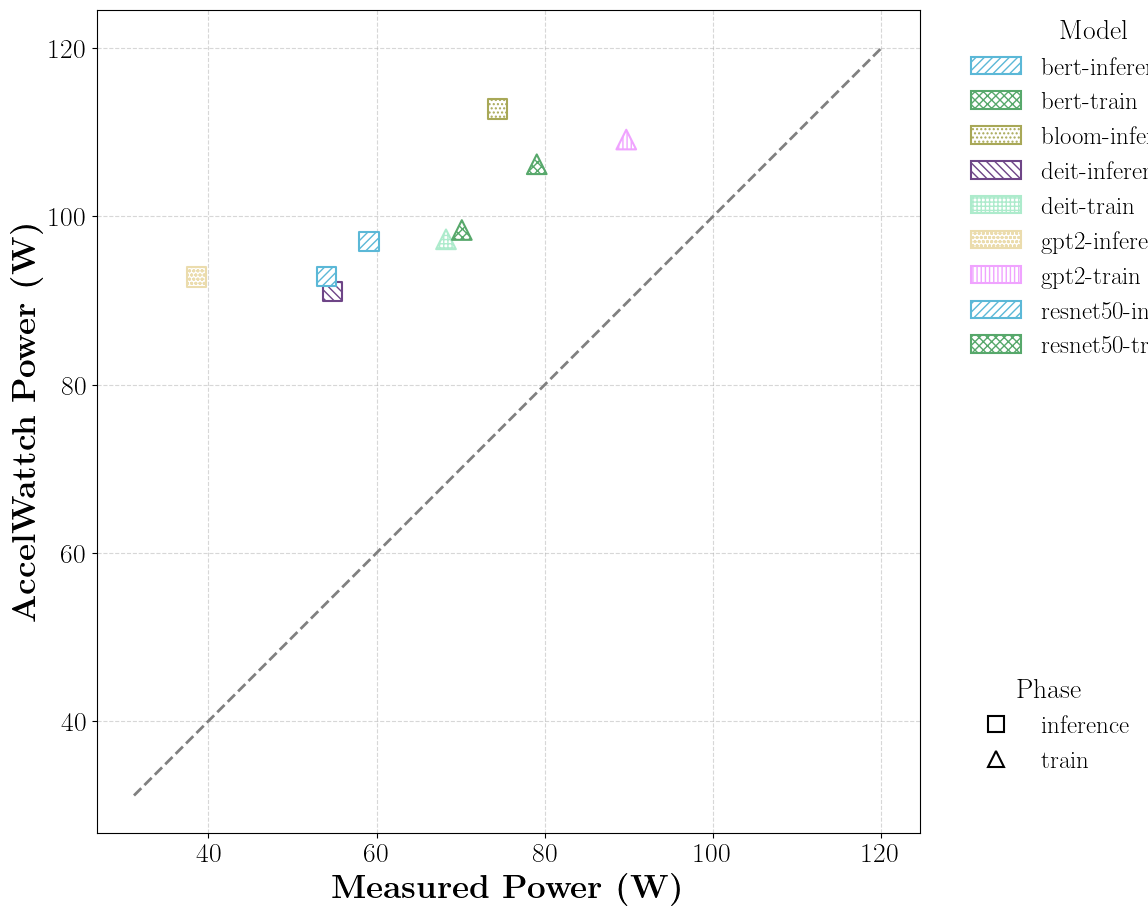

In [4]:
plot_df = (
    df
    .with_columns(
        pl.col("benchmark").str.split("-").list.slice(0, -1).list.join("-").alias("Model"),
        pl.col("benchmark").str.split("-").list.get(-1).alias("Phase")
    )
)

fig, ax = plt.subplots(figsize=(12, 12)) # Ensure square container

ax, hue_handles, style_handles = parity_plot(
    plot_df,
    x="measured_power_W",
    y="accel_power_W",
    hue="Model",  # Now using the clean column
    style="Phase", # Now using the clean column
    ax=ax,
    ms=200 # Slightly larger markers
)

# Axis Labels
ax.set_xlabel(r'\textbf{Measured Power (W)}')
ax.set_ylabel(r'\textbf{AccelWattch Power (W)}')

# --- Legend Placement ---
# We use bbox_to_anchor to push legends outside the plot area
# (1.05, 1.0) is top-right, just outside axes

# Add Model Legend (Top Right)
leg1 = ax.legend(
    handles=hue_handles, 
    title="Model",
    bbox_to_anchor=(1.05, 1.0), 
    loc='upper left',
    frameon=False,
    borderaxespad=0
)

# Add Legend 1 to artist so it isn't overwritten by Legend 2
ax.add_artist(leg1)

# Add Phase Legend (Below Model Legend)
# We adjust the y-coordinate (0.4) to sit below the first legend
leg2 = ax.legend(
    handles=style_handles, 
    title="Phase",
    bbox_to_anchor=(1.05, 0.2), 
    loc='upper left', 
    frameon=False,
    borderaxespad=0
)

plt.tight_layout()
# plt.savefig("parity_square.pdf", bbox_inches='tight')
plt.show()

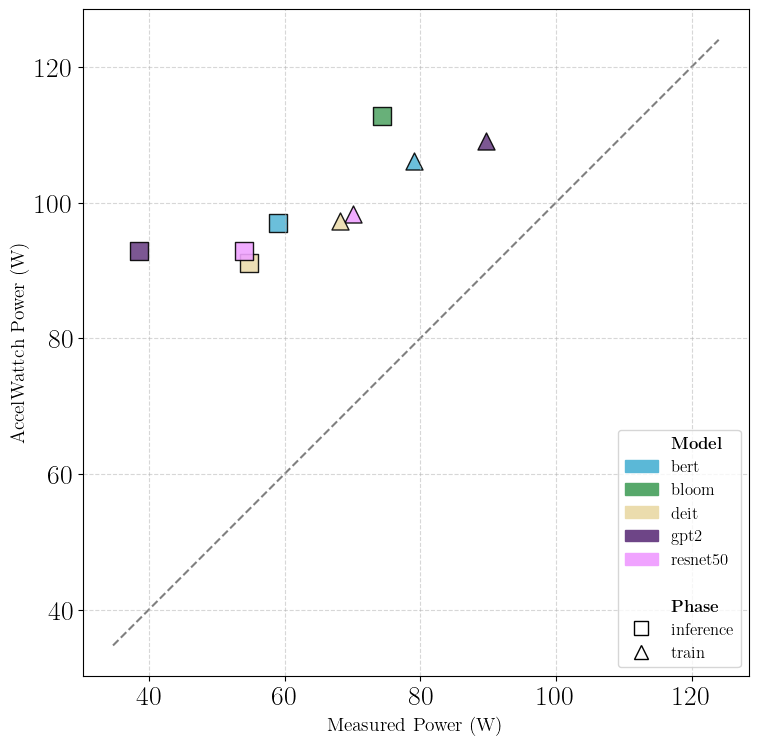

In [ ]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

df = pd.read_csv("main_df.csv")

plt.rcParams.update({
    "text.usetex": True,
    "font.size": "21",
    "font.family": "serif",
    # "font.serif": ["Palatino"],
    "legend.title_fontsize": "18",
})

# 2. Process Data: Extract Model and Phase
df['Model'] = df['benchmark'].apply(lambda x: x.split('-')[0])
df['Phase'] = df['benchmark'].apply(lambda x: x.split('-')[-1])

# 3. Define Mappings
unique_models = sorted(df['Model'].unique())
# Colors derived from the PDF style
colors = ['#5BB8D7', '#57A86B', '#EBDCAD', '#6E4587', '#F0A3FF']
model_color_map = {model: color for model, color in zip(unique_models, colors)}

phase_marker_map = {
    'inference': 's',  # Square
    'train': '^'       # Triangle
}

# 4. Create Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Scatter Plot Loop
for idx, row in df.iterrows():
    model = row['Model']
    phase = row['Phase']
    
    color = model_color_map.get(model, 'gray')
    marker = phase_marker_map.get(phase, 'o')
    
    ax.scatter(
        row['measured_power_W'],
        row['accel_power_W'],
        c=color,
        marker=marker,
        s=150,
        edgecolor='black',
        alpha=0.9
    )

# Diagonal Line (y=x)
all_vals = np.concatenate([df['measured_power_W'], df['accel_power_W']])
min_val = np.min(all_vals) * 0.9
max_val = np.max(all_vals) * 1.1
ax.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', zorder=0)

# Labels and Grid
ax.set_xlabel(r'Measured Power (W)', fontsize=14)
ax.set_ylabel(r'AccelWattch Power (W)', fontsize=14)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)

# 5. Construct Custom Legend
# Model Entries (Colors)
model_handles = []
for model in unique_models:
    patch = mpatches.Patch(color=model_color_map[model], label=model)
    model_handles.append(patch)

# Phase Entries (Markers)
phase_handles = []
for phase in sorted(df['Phase'].unique()):
    marker = phase_marker_map[phase]
    # Create a proxy artist for the marker (white face, black edge)
    handle = mlines.Line2D([], [], color='white', marker=marker, 
                          markerfacecolor='white', markeredgecolor='black', 
                          markersize=10, label=phase)
    phase_handles.append(handle)

# Combine into one list with Headers
final_handles = []
final_handles.append(mpatches.Patch(color='none', label=r'$\bf{Model}$')) # Bold Header
final_handles.extend(model_handles)
final_handles.append(mpatches.Patch(color='none', label='')) # Spacer
final_handles.append(mpatches.Patch(color='none', label=r'$\bf{Phase}$')) # Bold Header
final_handles.extend(phase_handles)

# Place Legend in Bottom Right
ax.legend(handles=final_handles, loc='lower right', frameon=True, fontsize=12)

plt.tight_layout()
plt.savefig('macro_power.png', dpi=300, bbox_inches='tight')
plt.show()

# Save processed data
# df.to_csv('processed_data.csv', index=False)

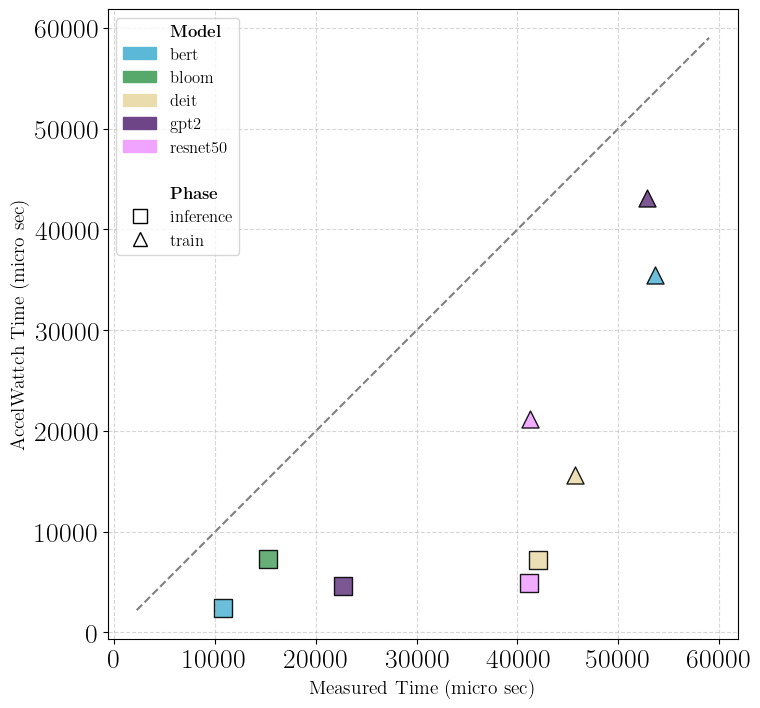

In [ ]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

df = pd.read_csv("main_df.csv")

plt.rcParams.update({
    "text.usetex": True,
    "font.size": "21",
    "font.family": "serif",
    # "font.serif": ["Palatino"],
    "legend.title_fontsize": "18",
})

# 2. Process Data: Extract Model and Phase
df['Model'] = df['benchmark'].apply(lambda x: x.split('-')[0])
df['Phase'] = df['benchmark'].apply(lambda x: x.split('-')[-1])

# 3. Define Mappings
unique_models = sorted(df['Model'].unique())
# Colors derived from the PDF style
colors = ['#5BB8D7', '#57A86B', '#EBDCAD', '#6E4587', '#F0A3FF']
model_color_map = {model: color for model, color in zip(unique_models, colors)}

phase_marker_map = {
    'inference': 's',  # Square
    'train': '^'       # Triangle
}

# 4. Create Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Scatter Plot Loop
for idx, row in df.iterrows():
    model = row['Model']
    phase = row['Phase']
    
    color = model_color_map.get(model, 'gray')
    marker = phase_marker_map.get(phase, 'o')
    
    ax.scatter(
        row['measured_time_us'],
        row['accel_time_us'],
        c=color,
        marker=marker,
        s=150,
        edgecolor='black',
        alpha=0.9
    )

# Diagonal Line (y=x)
all_vals = np.concatenate([df['measured_time_us'], df['accel_time_us']])
min_val = np.min(all_vals) * 0.9
max_val = np.max(all_vals) * 1.1
ax.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', zorder=0)

# Labels and Grid
ax.set_xlabel(r'Measured Time (micro sec)', fontsize=14)
ax.set_ylabel(r'AccelWattch Time (micro sec)', fontsize=14)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)

# 5. Construct Custom Legend
# Model Entries (Colors)
model_handles = []
for model in unique_models:
    patch = mpatches.Patch(color=model_color_map[model], label=model)
    model_handles.append(patch)

# Phase Entries (Markers)
phase_handles = []
for phase in sorted(df['Phase'].unique()):
    marker = phase_marker_map[phase]
    # Create a proxy artist for the marker (white face, black edge)
    handle = mlines.Line2D([], [], color='white', marker=marker, 
                          markerfacecolor='white', markeredgecolor='black', 
                          markersize=10, label=phase)
    phase_handles.append(handle)

# Combine into one list with Headers
final_handles = []
final_handles.append(mpatches.Patch(color='none', label=r'$\bf{Model}$')) # Bold Header
final_handles.extend(model_handles)
final_handles.append(mpatches.Patch(color='none', label='')) # Spacer
final_handles.append(mpatches.Patch(color='none', label=r'$\bf{Phase}$')) # Bold Header
final_handles.extend(phase_handles)

# Place Legend in Bottom Right
ax.legend(handles=final_handles, loc='upper left', frameon=True, fontsize=12)

plt.tight_layout()
plt.savefig('macro_time.png', dpi=300, bbox_inches='tight')
plt.show()

# Save processed data
# df.to_csv('processed_data.csv', index=False)